# Notebook 08 — Weather-Based Disease Risk Prediction (Rosa damascena)

## Goal

Predict the **seasonal risk** of three fungal diseases of Rosa damascena
from meteorological conditions at the Krasnovo field site:

- **Rose rust** (*Phragmidium mucronatum*)
- **Black spot** (*Diplocarpon rosae*)
- **Powdery mildew** (*Podosphaera pannosa*)

A separate risk model is trained per disease, because the exploratory
analysis (notebook 04) showed each has a distinct seasonal window and a
distinct set of weather drivers.

## Honest Framing of the Target

No daily field labels of disease presence exist for the Krasnovo site, so
this notebook does **not** train a field-validated outbreak classifier.
Instead it builds a **seasonal / climatic risk model**:

- The **ground truth** for *when* each disease is active comes from
  **real GBIF occurrence records** (observed seasonality across Europe).
- The model learns to map **Krasnovo weather** to that observed risk.
- Results are **validated** against (a) the GBIF seasonal windows and
  (b) a documented field observation of rust at the site in mid-May 2026.

This distinction is stated explicitly so the model's scope is not
overclaimed: it estimates weather-driven risk, not confirmed infection.

## Math / Method Focus

- Feature engineering on time series (7-day rolling and lag windows —
  motivated by hypothesis H2: "weather in the 7 days prior to observation").
- Time-aware train/test split (no random shuffling of a time series).
- Interpretable classification (Logistic Regression + tree-based models)
  with **feature importance** to answer which weather variables drive risk.

## Downy Mildew Excluded

*Peronospora sparsa* is dropped from the modelling: after the Europe
filter it has too few GBIF records for a reliable seasonal profile. Making
claims about its risk from such sparse data would violate the project's
data-honesty rule.

In [2]:
# ============================================================
# Imports (all libraries used in this notebook)
# ============================================================
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# scikit-learn - models, metrics, preprocessing
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ============================================================
# Reproducibility
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================
# Paths — local run (data already on disk). For Colab, replace
# PROJECT_ROOT with the mounted Drive base instead.
# ============================================================
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

WEATHER_CSV = PROJECT_ROOT / "data" / "raw" / "weather" / "krasnovo_weather_2015_2024.csv"
GBIF_CSV    = PROJECT_ROOT / "data" / "processed" / "gbif_rosa_diseases_clean.csv"

assert WEATHER_CSV.exists(), f"Missing weather file: {WEATHER_CSV}"
assert GBIF_CSV.exists(),    f"Missing GBIF file: {GBIF_CSV}"

# ============================================================
# Disease scope — species name -> project class name
# (downy_mildew / Peronospora sparsa excluded: too few records)
# ============================================================
DISEASES = {
    "rose_rust":      "Phragmidium mucronatum",
    "black_spot":     "Diplocarpon rosae",
    "powdery_mildew": "Podosphaera pannosa",
}

# ============================================================
# Weather features selected in EDA (notebook 04) as independent
# ============================================================
WEATHER_FEATURES = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
]

# ============================================================
# Europe bounding box (same as EDA) — keeps Northern-Hemisphere
# seasonality consistent with the Bulgarian field site
# ============================================================
EUROPE_BBOX = {"lon_min": -25, "lon_max": 45, "lat_min": 35, "lat_max": 72}

# ============================================================
# Plotting defaults
# ============================================================
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print("Config ready")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Diseases     : {list(DISEASES.keys())}")
print(f"  Features     : {WEATHER_FEATURES}")
print(f"  Random seed  : {RANDOM_SEED}")

Config ready
  Project root : h:\SoftUni\Machine Learning\Machine_Learning_Project
  Diseases     : ['rose_rust', 'black_spot', 'powdery_mildew']
  Features     : ['temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max']
  Random seed  : 42


## Loading the Data

Two sources are loaded:

1. **Krasnovo daily weather** (2015–2024) — the model's features.
2. **GBIF disease occurrences** — filtered to the three in-scope diseases
   and to the European bounding box used in the EDA, so the observed
   seasonality reflects the same Northern-Hemisphere climate as the field
   site. Records without a valid month are dropped (month is what defines
   the seasonal signal).

In [3]:
# ============================================================
# Load weather data
# ============================================================
weather = pd.read_csv(WEATHER_CSV, parse_dates=["date"])
weather = weather.sort_values("date").reset_index(drop=True)
weather["month"]       = weather["date"].dt.month
weather["day_of_year"] = weather["date"].dt.dayofyear
weather["year"]        = weather["date"].dt.year

print("Weather data")
print(f"  Rows        : {len(weather):,}")
print(f"  Date range  : {weather['date'].min().date()} -> {weather['date'].max().date()}")
print(f"  Missing     : {int(weather[WEATHER_FEATURES].isna().sum().sum())} "
      f"in selected features")

# ============================================================
# Load GBIF occurrences and restrict to scope
# ============================================================
gbif = pd.read_csv(GBIF_CSV, low_memory=False)

# Keep only the three in-scope species
species_in_scope = list(DISEASES.values())
gbif = gbif[gbif["query_species"].isin(species_in_scope)].copy()

# Europe bounding box (same as EDA)
gbif = gbif[
    gbif["decimalLongitude"].between(EUROPE_BBOX["lon_min"], EUROPE_BBOX["lon_max"]) &
    gbif["decimalLatitude"].between(EUROPE_BBOX["lat_min"], EUROPE_BBOX["lat_max"])
].copy()

# Drop records without a valid month (month drives the seasonal signal)
gbif = gbif.dropna(subset=["month"])
gbif["month"] = gbif["month"].astype(int)

# Map species -> project class name
species_to_class = {v: k for k, v in DISEASES.items()}
gbif["disease"] = gbif["query_species"].map(species_to_class)

print("\nGBIF occurrences (Europe, in-scope diseases, valid month)")
print(f"  Total records: {len(gbif):,}")
print(gbif["disease"].value_counts().to_string())

# ============================================================
# Sanity checks
# ============================================================
assert weather[WEATHER_FEATURES].isna().sum().sum() == 0, "Unexpected NaNs in weather features"
assert set(gbif["disease"].unique()) == set(DISEASES.keys()), "Unexpected disease classes"
assert gbif["month"].between(1, 12).all(), "Invalid month values in GBIF"
print("\nSanity checks passed.")

Weather data
  Rows        : 3,653
  Date range  : 2015-01-01 -> 2024-12-31
  Missing     : 0 in selected features

GBIF occurrences (Europe, in-scope diseases, valid month)
  Total records: 6,751
disease
rose_rust         2728
powdery_mildew    2519
black_spot        1504

Sanity checks passed.


## Weather Seasonal Cycle at Krasnovo

Before modelling disease risk, we establish the **climatic baseline**: how
each of the four selected weather features varies across the year, averaged
over 2015–2024. The monthly mean is shown with a ±1 standard-deviation band
to convey year-to-year variability.

The two disease-risk windows identified in the EDA (notebook 04) are shaded:
**spring (Apr–Jun)** and **autumn (Sep–Oct)**. This sets up the question the
model will answer — whether the weather inside those windows is distinctive
enough to predict the observed disease seasonality.

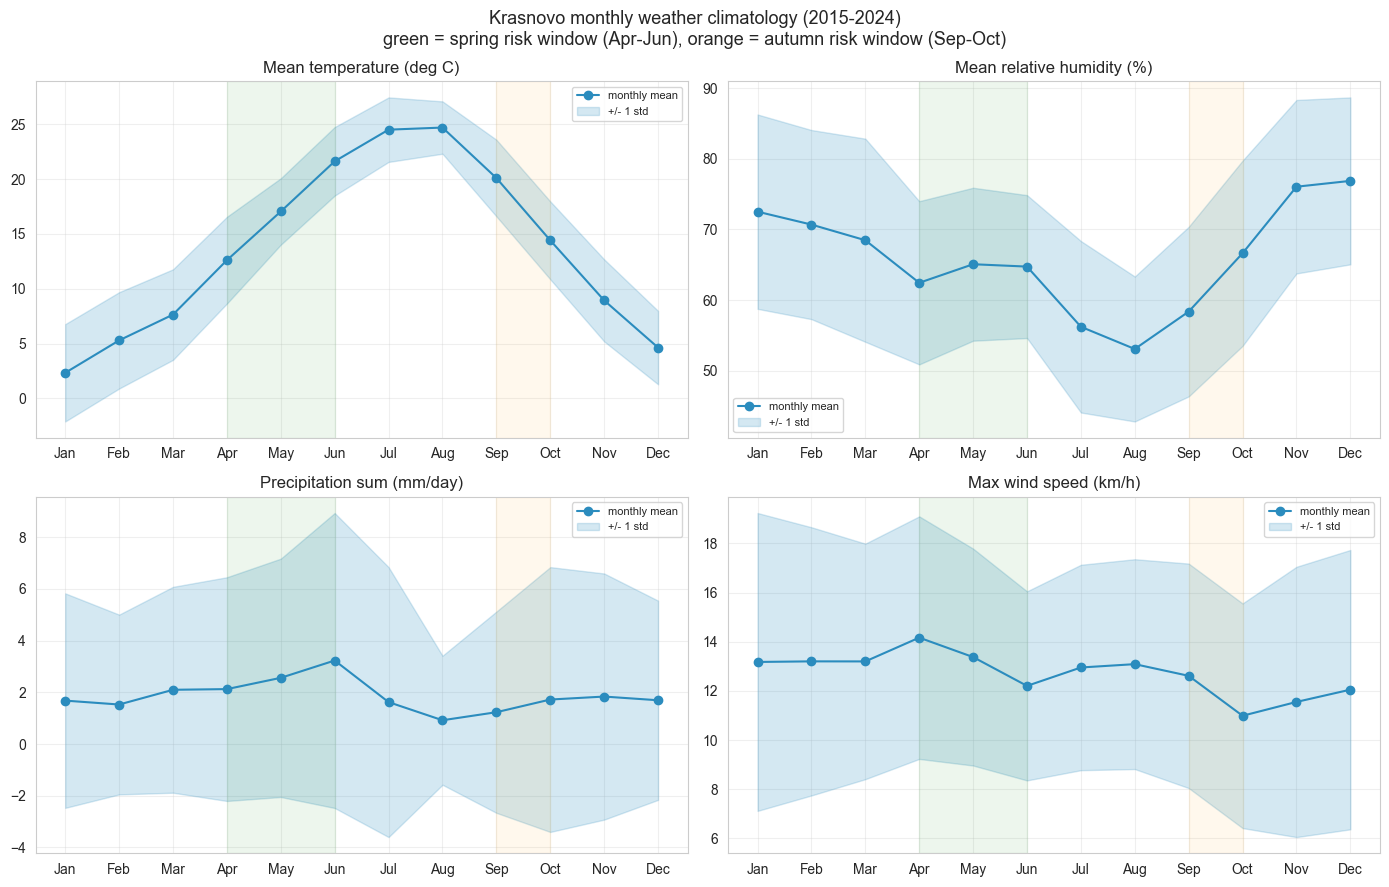

Monthly mean of each feature:
     temperature_2m_mean  relative_humidity_2m_mean  precipitation_sum  wind_speed_10m_max
Jan                  2.3                       72.5                1.7                13.2
Feb                  5.3                       70.7                1.5                13.2
Mar                  7.6                       68.5                2.1                13.2
Apr                 12.6                       62.4                2.1                14.2
May                 17.0                       65.1                2.6                13.4
Jun                 21.6                       64.7                3.2                12.2
Jul                 24.5                       56.2                1.6                13.0
Aug                 24.7                       53.1                0.9                13.1
Sep                 20.1                       58.4                1.2                12.6
Oct                 14.4                       66.6         

In [4]:
# ============================================================
# Monthly climatology of the four weather features (2015-2024)
# ============================================================
monthly = weather.groupby("month")[WEATHER_FEATURES].agg(["mean", "std"])

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
feature_titles = {
    "temperature_2m_mean":       "Mean temperature (deg C)",
    "relative_humidity_2m_mean": "Mean relative humidity (%)",
    "precipitation_sum":         "Precipitation sum (mm/day)",
    "wind_speed_10m_max":        "Max wind speed (km/h)",
}
months = list(range(1, 13))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, feat in zip(axes, WEATHER_FEATURES):
    m = monthly[(feat, "mean")].values
    s = monthly[(feat, "std")].values
    ax.plot(months, m, marker="o", color="#2b8cbe", label="monthly mean")
    ax.fill_between(months, m - s, m + s, alpha=0.2, color="#2b8cbe", label="+/- 1 std")

    # EDA risk windows: spring (Apr-Jun) green, autumn (Sep-Oct) orange
    ax.axvspan(4, 6, color="green",  alpha=0.07)
    ax.axvspan(9, 10, color="orange", alpha=0.07)

    ax.set_title(feature_titles[feat])
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="best")

fig.suptitle(
    "Krasnovo monthly weather climatology (2015-2024)\n"
    "green = spring risk window (Apr-Jun), orange = autumn risk window (Sep-Oct)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ============================================================
# Compact numeric summary of the monthly means
# ============================================================
summary = monthly.xs("mean", axis=1, level=1).round(1)
summary.index = month_labels
print("Monthly mean of each feature:")
print(summary.to_string())

### Observations

The climatology shows a strong, regular seasonal cycle and three of the
four features carry a clear seasonal signal:

- **Temperature** rises from ~2 deg C (Jan) to a ~25 deg C plateau
  (Jul–Aug), then falls. The spring window (Apr–Jun) spans the steep
  warming phase (12.6 -> 21.6 deg C); the autumn window (Sep–Oct) the
  cooling phase (20.1 -> 14.4 deg C).
- **Relative humidity** is inversely related to temperature: highest in
  winter (Nov–Dec ~76–77%), lowest in mid-summer (Aug 53%). Both risk
  windows sit at intermediate humidity (58–66%).
- **Precipitation** peaks in late spring / early summer (Jun 3.2 mm/day,
  May 2.6) and bottoms out in August (0.9). The spring risk window
  coincides with the wettest part of the year.
- **Wind speed** is nearly flat across the year (11–14 km/h) with only a
  weak April bump. It is the feature with the least seasonal structure —
  a candidate to be the weakest predictor, to be checked via feature
  importance later.

**Tie to disease risk (interpretation):** the combination inside the
spring window — moderate warming temperatures plus the year's highest
precipitation — is the kind of condition generally favourable for fungal
infection (leaf wetness plus mild temperatures). Mid-summer (Jul–Aug) is
hot and dry with the lowest humidity, matching the EDA's "low-risk"
period. This is consistent with, but does not by itself prove, the
observed disease seasonality — that is what the GBIF profile and the
models test next.

*Note:* the ±1 std band on precipitation dips below zero in the plot;
this is an artefact of using mean ± std on a non-negative, right-skewed
variable and should not be read literally.

## Observed Disease Seasonality (GBIF)

This is the empirical backbone of the target. For each disease we compute
the **share of its GBIF occurrences that fall in each month** (normalised
within the disease, so we compare the *shape* of each season, not the raw
record counts). The peak months define the observed risk window that the
weather model will be trained to reproduce.

A caveat kept in mind throughout: GBIF records reflect **observer effort**
as well as true disease presence (more people record in the growing
season). The relative month-to-month shape per disease is still
informative, and it agreed with the Bulgarian weather windows in the EDA.

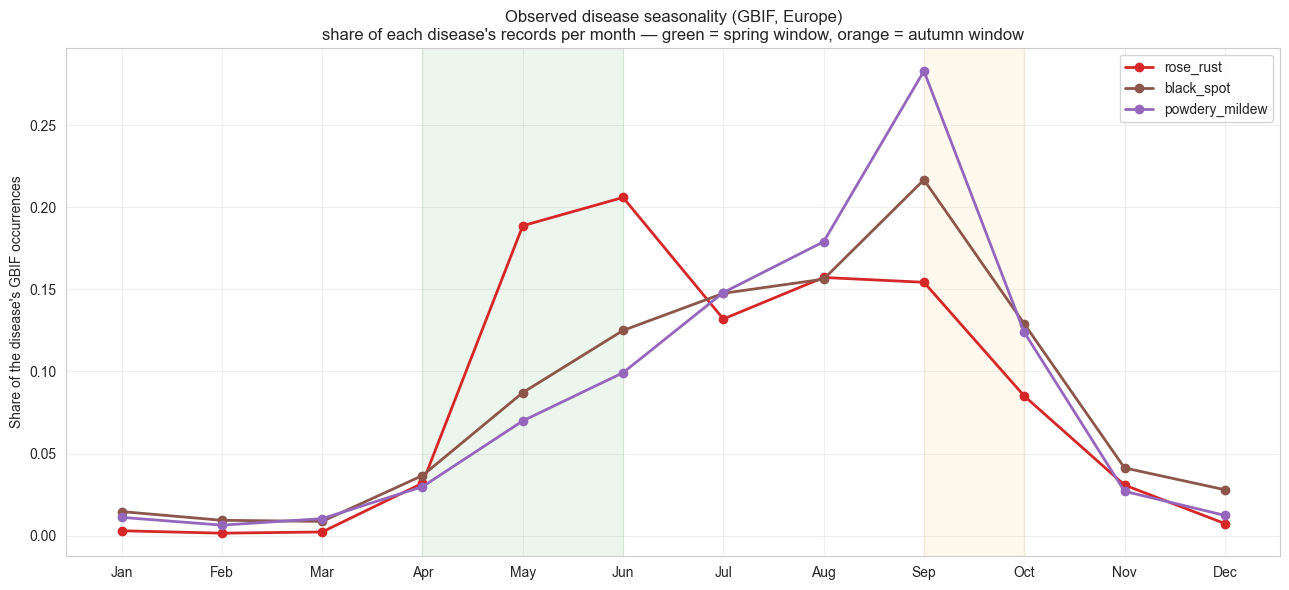

Peak months (by share of the disease's occurrences):
  rose_rust       : Jun (21%), May (19%), Aug (16%)
  black_spot      : Sep (22%), Aug (16%), Jul (15%)
  powdery_mildew  : Sep (28%), Aug (18%), Jul (15%)


In [5]:
# ============================================================
# Monthly seasonality per disease (share of each disease's records)
# ============================================================
monthly_counts = (
    gbif.groupby(["disease", "month"]).size()
        .unstack(fill_value=0)
        .reindex(columns=range(1, 13), fill_value=0)
)
monthly_share = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)

colors = {"rose_rust": "#d62728", "black_spot": "#8c564b", "powdery_mildew": "#9467bd"}

fig, ax = plt.subplots(figsize=(13, 6))
for disease in DISEASES:
    ax.plot(range(1, 13), monthly_share.loc[disease].values,
            marker="o", linewidth=2, label=disease, color=colors[disease])

ax.axvspan(4, 6,  color="green",  alpha=0.07)
ax.axvspan(9, 10, color="orange", alpha=0.07)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel("Share of the disease's GBIF occurrences")
ax.set_title(
    "Observed disease seasonality (GBIF, Europe)\n"
    "share of each disease's records per month — "
    "green = spring window, orange = autumn window",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Peak months per disease
# ============================================================
print("Peak months (by share of the disease's occurrences):")
for disease in DISEASES:
    top = monthly_share.loc[disease].sort_values(ascending=False).head(3)
    months_str = ", ".join(f"{month_labels[m - 1]} ({v:.0%})" for m, v in top.items())
    print(f"  {disease:<16}: {months_str}")

### Observations

The three diseases have distinct, well-separated seasonal profiles:

- **rose_rust** peaks earliest — **May–Jun** (19–21% of its records), in
  the spring window. This **matches the documented field observation of
  rust at Krasnovo in mid-May 2026**, an independent confirmation of the
  GBIF-derived season.
- **black_spot** is summer–autumn, peaking in **Sep (22%)** with Aug–Jul
  close behind.
- **powdery_mildew** has the sharpest single peak — **Sep (28%)** — in the
  autumn window, with a broad Jul–Sep shoulder.

All three overlap in late summer (Aug–Sep); the main discriminating
feature is **rust's spring shift** versus the autumn-leaning black_spot
and powdery_mildew. This separation is exactly what justifies the
**per-disease** modelling decision — a single combined risk model would
blur three genuinely different seasons.

This confirms the EDA (notebook 04) seasonality and the Bulgarian risk
windows. The known observer-effort bias in GBIF is noted, but the distinct
per-disease *shapes* (not just overall counts) are informative and
agree with an independent local observation.

## Constructing the Risk Target — Continuous Risk Index

A first attempt used a binary "in-season" label (month share > 1/12). It
failed: all three diseases are active across the whole warm half-year, so
the binary windows collapsed to almost the same May–Oct span and erased the
per-disease distinction. The discriminating information is in *when each
disease peaks*, not *whether a season exists*.

So the target is a **continuous per-disease risk index** in `[0, 1]`:

> For each disease, the index of a month = that month's share of the
> disease's GBIF occurrences, **normalised by the disease's peak month**
> (so the peak month = 1.0 and the off-season approaches 0).

This preserves the full seasonal *shape* — rust's spring peak, powdery
mildew's autumn peak — with no hand-tuned thresholds. The index is constant
within a calendar month and is assigned to every day of the weather record.

**Modelling.** Each disease gets a **regression** model (Ridge as the linear
interpretable baseline, plus tree-based RandomForest / GradientBoosting
regressors). Evaluation uses R² and MAE. Features remain **weather-only**
(no calendar input), so the model must infer the risk level from actual
weather conditions — the substance of hypothesis H2.

In [7]:
# ============================================================
# Continuous per-disease seasonal risk index (0-1), constant within a month.
# index = month's share of the disease's occurrences, normalised by the
# disease's peak month (peak = 1.0, off-season ~ 0).
# ============================================================
risk_index = monthly_share.div(monthly_share.max(axis=1), axis=0)  # rows=disease, cols=month

print("Per-disease monthly risk index (peak month = 1.00):")
ri_display = risk_index.copy()
ri_display.columns = month_labels
print(ri_display.round(2).to_string())

# ============================================================
# Map the index onto the daily weather table -> regression targets
# ============================================================
target = weather[["date", "year", "month", "day_of_year"] + WEATHER_FEATURES].copy()
for disease in DISEASES:
    target[f"risk_{disease}"] = target["month"].map(risk_index.loc[disease])

# ============================================================
# Summary per disease
# ============================================================
print("\nRisk index summary per disease (over all 3,653 days):")
for disease in DISEASES:
    col = target[f"risk_{disease}"]
    peak_month = month_labels[int(risk_index.loc[disease].idxmax()) - 1]
    print(f"  risk_{disease:<16}: min={col.min():.2f}  mean={col.mean():.2f}  "
          f"max={col.max():.2f}  peak={peak_month}")

print(f"\nTarget table shape: {target.shape}")

Per-disease monthly risk index (peak month = 1.00):
                 Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
disease                                                                               
black_spot      0.07  0.04  0.04  0.17  0.40  0.58  0.68  0.72  1.00  0.60  0.19  0.13
powdery_mildew  0.04  0.02  0.04  0.11  0.25  0.35  0.52  0.63  1.00  0.44  0.10  0.04
rose_rust       0.01  0.01  0.01  0.15  0.92  1.00  0.64  0.76  0.75  0.41  0.15  0.04

Risk index summary per disease (over all 3,653 days):
  risk_rose_rust       : min=0.01  mean=0.41  max=1.00  peak=Jun
  risk_black_spot      : min=0.04  mean=0.39  max=1.00  peak=Sep
  risk_powdery_mildew  : min=0.02  mean=0.30  max=1.00  peak=Sep

Target table shape: (3653, 11)


### Observations

The continuous index restores the per-disease distinction the binary label
lost. The peak month differs meaningfully: **rose_rust peaks in Jun with an
already-high May (0.92)** — a spring-led season that matches the mid-May
field observation — while **black_spot and powdery_mildew both peak in Sep**,
an autumn-led season. Mean risk is similar across diseases (0.30–0.41), so
none is trivially "always high"; the signal lives in the seasonal shape,
which is exactly what the heatmap below makes visible.

## Visualisation: Seasonal Risk Calendar

The risk index is shown as a disease × month heatmap. This is the clearest
single view of the target: each row is one disease's seasonal risk profile,
normalised so its peak month is 1.0. Reading across a row shows when that
disease's risk rises and falls; reading down a column compares the three
diseases in a given month.

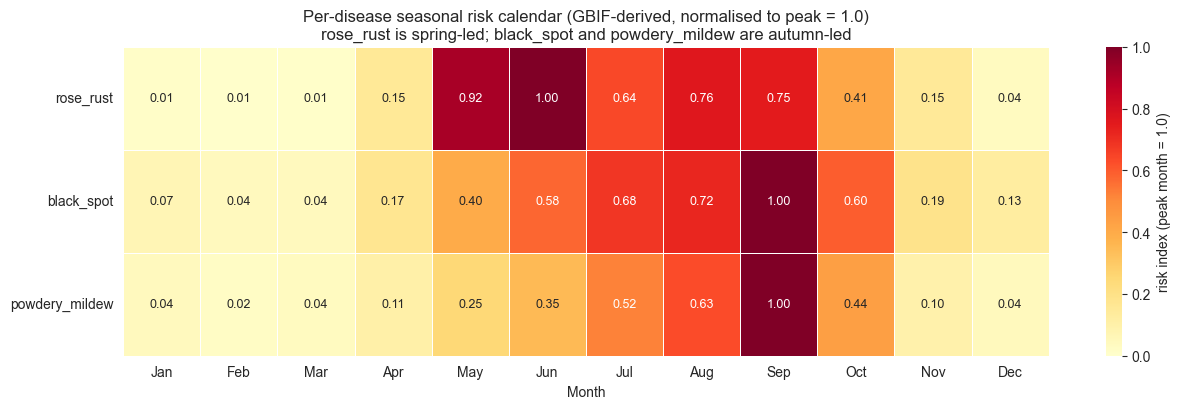

In [8]:
# ============================================================
# Seasonal risk calendar: disease x month heatmap of the risk index
# ============================================================
hm = risk_index.copy()
hm.columns = month_labels
hm = hm.reindex(["rose_rust", "black_spot", "powdery_mildew"])  # spring-led first

fig, ax = plt.subplots(figsize=(13, 4.2))
sns.heatmap(
    hm,
    annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "risk index (peak month = 1.0)"},
    annot_kws={"fontsize": 9},
    ax=ax,
)
ax.set_title(
    "Per-disease seasonal risk calendar (GBIF-derived, normalised to peak = 1.0)\n"
    "rose_rust is spring-led; black_spot and powdery_mildew are autumn-led",
    fontsize=12,
)
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Observations

The calendar makes the three seasonal signatures immediately legible:

- **rose_rust** — a bright spring band (May 0.92, Jun 1.00) that stays
  elevated through summer (Jul–Sep 0.64–0.76). Spring-led.
- **black_spot** — a smooth ramp from April (0.17) to a single Sep peak
  (1.00), broad across summer–autumn.
- **powdery_mildew** — the sharpest profile: low until July, then a steep
  rise to a narrow Sep peak (1.00).

Reading **down the columns** shows the discriminating structure the models
must exploit: in **May**, rust dominates (0.92 vs 0.40 vs 0.25); by
**September** all three are high but black_spot and powdery_mildew lead
(1.00 vs rust's 0.75). The same instantaneous temperature occurs twice a
year (spring warming and autumn cooling), so a model using only same-day
weather will struggle to tell May from September — which motivates the
**trend features** added next.

## Feature Engineering — Weather History and Trend

The models use **weather-only features, no calendar input**. To let them
separate the spring rust season from the autumn black_spot / powdery_mildew
season — which can share the same daily temperature — we add features that
encode **recent history and direction of change**:

- **7-day rolling means** of all four variables — directly the "weather in
  the 7 days prior" of hypothesis H2.
- **14-day cumulative precipitation** — a proxy for sustained leaf wetness,
  the key driver of fungal infection.
- **14-day temperature and humidity trends** (change in the 7-day mean over
  the last two weeks) — *positive in spring (warming), negative in autumn
  (cooling)*. This is the feature that can break the spring/autumn
  ambiguity without ever looking at the calendar.

All windows are **trailing** (past days only), so there is no look-ahead
leakage. The warm-up rows with incomplete windows are dropped.

In [9]:
# ============================================================
# Weather-only engineered features (NO calendar columns).
# All rolling windows are trailing -> no look-ahead leakage.
# ============================================================
df = target.sort_values("date").reset_index(drop=True)

# 7-day rolling means (H2: "weather in the 7 days prior")
df["temp_roll7"]     = df["temperature_2m_mean"].rolling(7,  min_periods=7).mean()
df["humidity_roll7"] = df["relative_humidity_2m_mean"].rolling(7,  min_periods=7).mean()
df["precip_roll7"]   = df["precipitation_sum"].rolling(7,  min_periods=7).mean()
df["wind_roll7"]     = df["wind_speed_10m_max"].rolling(7,  min_periods=7).mean()

# 14-day cumulative precipitation (sustained leaf wetness)
df["precip_sum14"]   = df["precipitation_sum"].rolling(14, min_periods=14).sum()

# 14-day trends in the 7-day mean: positive = warming/moistening,
# negative = cooling/drying -> separates spring from autumn
df["temp_trend14"]     = df["temp_roll7"]     - df["temp_roll7"].shift(14)
df["humidity_trend14"] = df["humidity_roll7"] - df["humidity_roll7"].shift(14)

# Drop warm-up rows with incomplete windows
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} warm-up rows; {len(df):,} rows remain "
      f"({df['date'].min().date()} -> {df['date'].max().date()})")

# ============================================================
# Final feature set
# ============================================================
FEATURE_COLS = [
    "temperature_2m_mean", "relative_humidity_2m_mean",
    "precipitation_sum", "wind_speed_10m_max",
    "temp_roll7", "humidity_roll7", "precip_roll7", "wind_roll7",
    "precip_sum14", "temp_trend14", "humidity_trend14",
]
print(f"\n{len(FEATURE_COLS)} weather-only features (no calendar):")
for c in FEATURE_COLS:
    print(f"  {c}")

print("\nFeature summary:")
print(df[FEATURE_COLS].describe().round(2).to_string())

Dropped 20 warm-up rows; 3,633 rows remain (2015-01-21 -> 2024-12-31)

11 weather-only features (no calendar):
  temperature_2m_mean
  relative_humidity_2m_mean
  precipitation_sum
  wind_speed_10m_max
  temp_roll7
  humidity_roll7
  precip_roll7
  wind_roll7
  precip_sum14
  temp_trend14
  humidity_trend14

Feature summary:
       temperature_2m_mean  relative_humidity_2m_mean  precipitation_sum  wind_speed_10m_max  temp_roll7  humidity_roll7  precip_roll7  wind_roll7  precip_sum14  temp_trend14  humidity_trend14
count              3633.00                    3633.00            3633.00             3633.00     3633.00         3633.00       3633.00     3633.00       3633.00       3633.00           3633.00
mean                 13.76                      65.87               1.86               12.72       13.76           65.88          1.86       12.72         25.98          0.01              0.03
std                   8.38                      14.21               4.42                4.95  

### Observations

The engineered features behave as intended:

- **Rolling means** (`*_roll7`) track their instantaneous counterparts
  closely (e.g. temp mean 13.76 vs roll7 13.76) — expected, since a 7-day
  mean is a smoothed version of the same signal.
- **`temp_trend14`** is centred near zero (mean 0.01) with a symmetric
  spread (−11.8 to +14.3): strong positive values mark spring warming,
  strong negative values autumn cooling — exactly the directional signal
  needed to break the spring/autumn temperature ambiguity.
- **`humidity_trend14`** spans −34 to +36, and **`precip_sum14`** (mean 26
  mm, max 165) captures sustained-wetness episodes that single-day
  precipitation misses.

Only 20 warm-up rows were dropped; 3,633 remain across the full 2015–2024
span. The feature set is ready for modelling.

## Visualisation: Feature–Risk Correlation

Before fitting models, we inspect the linear relationship between each
weather feature and each disease's risk index (Pearson correlation). This
is a quick, model-free preview: features that correlate strongly with a
disease's risk are the ones a model should rely on. We expect the
**trend features** to behave differently across the spring-led (rust) and
autumn-led (black_spot, powdery_mildew) diseases.

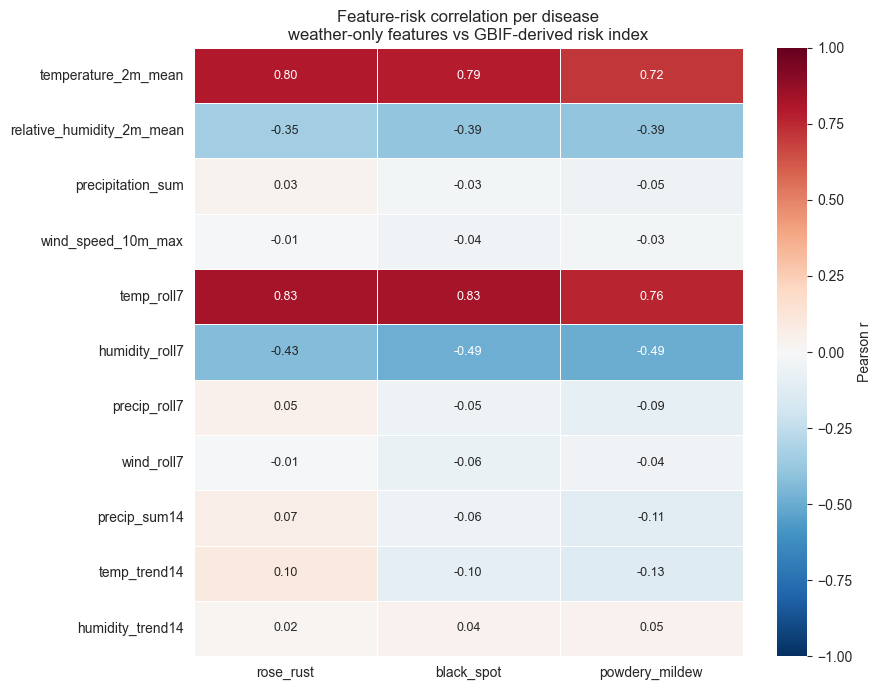

Top 3 features by |correlation| per disease:
  rose_rust       : temp_roll7 (+0.83), temperature_2m_mean (+0.80), humidity_roll7 (-0.43)
  black_spot      : temp_roll7 (+0.83), temperature_2m_mean (+0.79), humidity_roll7 (-0.49)
  powdery_mildew  : temp_roll7 (+0.76), temperature_2m_mean (+0.72), humidity_roll7 (-0.49)


In [10]:
# ============================================================
# Pearson correlation of each feature with each disease's risk index
# ============================================================
risk_cols = [f"risk_{d}" for d in DISEASES]
corr = df[FEATURE_COLS + risk_cols].corr()
corr_ft = corr.loc[FEATURE_COLS, risk_cols]
corr_ft.columns = list(DISEASES.keys())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_ft, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Pearson r"}, annot_kws={"fontsize": 9}, ax=ax,
)
ax.set_title(
    "Feature-risk correlation per disease\n"
    "weather-only features vs GBIF-derived risk index",
    fontsize=12,
)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# Strongest correlates per disease
# ============================================================
print("Top 3 features by |correlation| per disease:")
for d in DISEASES:
    s = corr_ft[d].sort_values(key=lambda x: x.abs(), ascending=False)
    top = ", ".join(f"{f} ({v:+.2f})" for f, v in s.head(3).items())
    print(f"  {d:<16}: {top}")

### Observations

The correlations expose both the dominant signal and a modelling challenge:

- **Temperature dominates, and identically for all three diseases**:
  `temp_roll7` correlates +0.83 / +0.83 / +0.76 and same-day temperature
  +0.80 / +0.79 / +0.72. Risk rises with warmth — but this signal is
  **shared**, so it cannot by itself tell the three diseases apart.
- **Humidity is a moderate negative correlate** (−0.43 to −0.49 on
  `humidity_roll7`): higher risk in the drier, warmer part of the year.
- **Precipitation and wind are near zero linearly** (|r| < 0.11) — weak
  *linear* predictors (precipitation may still matter non-linearly for
  infection).
- **The trend features have weak linear correlation** (`temp_trend14`
  +0.10 / −0.10 / −0.13). This is expected, not disappointing: their role
  is **directional and non-linear** — "warming at high temperature" (spring,
  rust) versus "cooling at high temperature" (autumn, mildew). A Pearson
  coefficient cannot capture an interaction like that, but **tree-based
  models can**.

**Implication for modelling.** Because the strong linear signal
(temperature) is shared across diseases, a purely linear model (Ridge) is
expected to produce similar, temperature-driven predictions for all three
and to struggle to separate the spring-led from the autumn-led seasons. The
per-disease distinction should instead come from **non-linear interactions**
involving the trend features — so we expect the **tree-based regressors to
outperform Ridge**, especially on rust. The next cells test this directly.

## Time-Aware Train/Test Split

A weather time series must **not** be split randomly — that would leak
information between adjacent days. We hold out the **last two full years
(2023–2024)** as the test set and train on **2015–2022**. This tests
whether weather from unseen years can reproduce the seasonal risk curve.
Features are standardised with statistics fitted on the training set only.

In [11]:
TRAIN_YEARS = list(range(2015, 2023))   # 2015-2022
TEST_YEARS  = [2023, 2024]

train_mask = df["year"].isin(TRAIN_YEARS)
test_mask  = df["year"].isin(TEST_YEARS)

X_train = df.loc[train_mask, FEATURE_COLS].values
X_test  = df.loc[test_mask,  FEATURE_COLS].values

scaler = StandardScaler().fit(X_train)          # fit on train only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {int(train_mask.sum()):,} days  ({TRAIN_YEARS[0]}-{TRAIN_YEARS[-1]})")
print(f"Test : {int(test_mask.sum()):,} days  ({TEST_YEARS[0]}-{TEST_YEARS[-1]})")
print(f"Features: {len(FEATURE_COLS)}")

Train: 2,902 days  (2015-2022)
Test : 731 days  (2023-2024)
Features: 11


## Training the Per-Disease Risk Regressors

Each disease gets three regressors:

- **Ridge** — the linear, interpretable baseline (coefficients).
- **RandomForest** and **GradientBoosting** — tree-based models that can
  capture non-linear interactions (e.g. trend × temperature).

Evaluation uses **R²** (variance of the risk curve explained) and **MAE**
(mean absolute error on the 0–1 risk index) on the held-out 2023–2024 test
years.

In [12]:
MODEL_NAMES = ["Ridge", "RandomForest", "GradientBoosting"]

def make_models():
    return {
        "Ridge":            Ridge(alpha=1.0),
        "RandomForest":     RandomForestRegressor(n_estimators=300,
                                                  random_state=RANDOM_SEED, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
    }

results       = {}   # (disease, model) -> {"r2":, "mae":}
predictions   = {}   # (disease, model) -> y_pred on test
models_fitted = {}   # (disease, model) -> fitted estimator
y_test_by_disease = {}

for disease in DISEASES:
    y_train = df.loc[train_mask, f"risk_{disease}"].values
    y_test  = df.loc[test_mask,  f"risk_{disease}"].values
    y_test_by_disease[disease] = y_test

    for name, model in make_models().items():
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
        results[(disease, name)]       = {
            "r2":  r2_score(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
        }
        predictions[(disease, name)]   = pred
        models_fitted[(disease, name)] = model

# ============================================================
# Results table
# ============================================================
print(f"{'Disease':<16}{'Model':<18}{'R2':>8}{'MAE':>8}")
print("-" * 50)
for disease in DISEASES:
    for name in MODEL_NAMES:
        r = results[(disease, name)]
        print(f"{disease:<16}{name:<18}{r['r2']:>8.3f}{r['mae']:>8.3f}")
    print("-" * 50)

# Best model per disease (by R2)
print("\nBest model per disease (by R2):")
for disease in DISEASES:
    best = max(MODEL_NAMES, key=lambda n: results[(disease, n)]["r2"])
    print(f"  {disease:<16}: {best}  (R2={results[(disease, best)]['r2']:.3f})")

Disease         Model                   R2     MAE
--------------------------------------------------
rose_rust       Ridge                0.672   0.169
rose_rust       RandomForest         0.758   0.106
rose_rust       GradientBoosting     0.763   0.115
--------------------------------------------------
black_spot      Ridge                0.779   0.112
black_spot      RandomForest         0.833   0.085
black_spot      GradientBoosting     0.849   0.085
--------------------------------------------------
powdery_mildew  Ridge                0.684   0.118
powdery_mildew  RandomForest         0.783   0.083
powdery_mildew  GradientBoosting     0.781   0.090
--------------------------------------------------

Best model per disease (by R2):
  rose_rust       : GradientBoosting  (R2=0.763)
  black_spot      : GradientBoosting  (R2=0.849)
  powdery_mildew  : RandomForest  (R2=0.783)


### Observations

The results confirm the hypothesis from the correlation analysis:

- **Tree-based models beat Ridge on every disease** (+0.07 to +0.10 R²).
  The shared linear temperature signal caps the linear model; the
  non-linear interactions (trend × temperature) add the rest.
- **GradientBoosting wins rose_rust and black_spot; RandomForest edges
  powdery_mildew** (0.783 vs GB 0.781 — effectively tied). The two
  tree models are close throughout.
- **black_spot is the easiest** (R² 0.849) — a smooth, broad summer–autumn
  season is well explained by temperature and humidity.
- **rose_rust is the hardest for Ridge** (0.672, the lowest score), exactly
  as predicted: its spring season shares daily temperatures with autumn, so
  a linear model cannot separate them. The tree models recover most of the
  gap (0.763), evidence that the **trend features carry the spring/autumn
  distinction** — even though their *linear* correlation was near zero.
- **MAE is 0.08–0.12** on the 0–1 index for the tree models: predicted risk
  lands within ~10% of the GBIF-derived value.

Overall, **weather alone explains 76–85% of the seasonal risk variance**,
supporting hypothesis H2. *Honest scope:* this is variance of the
GBIF-derived seasonal curve explained by weather — not field-outbreak
accuracy, for which no local labels exist.

## Visualisation: Predicted vs Actual Risk on the Held-Out Years

For each disease the best model's **daily predicted risk** is overlaid on
the **actual GBIF-derived risk index** across the 2023–2024 test years. The
actual index is piecewise-constant per month (it is a seasonal target),
while the prediction varies daily with the weather. The question is whether
the predicted curve tracks each disease's season — in particular whether
**rust risk rises in spring** and the **autumn diseases peak in September**.

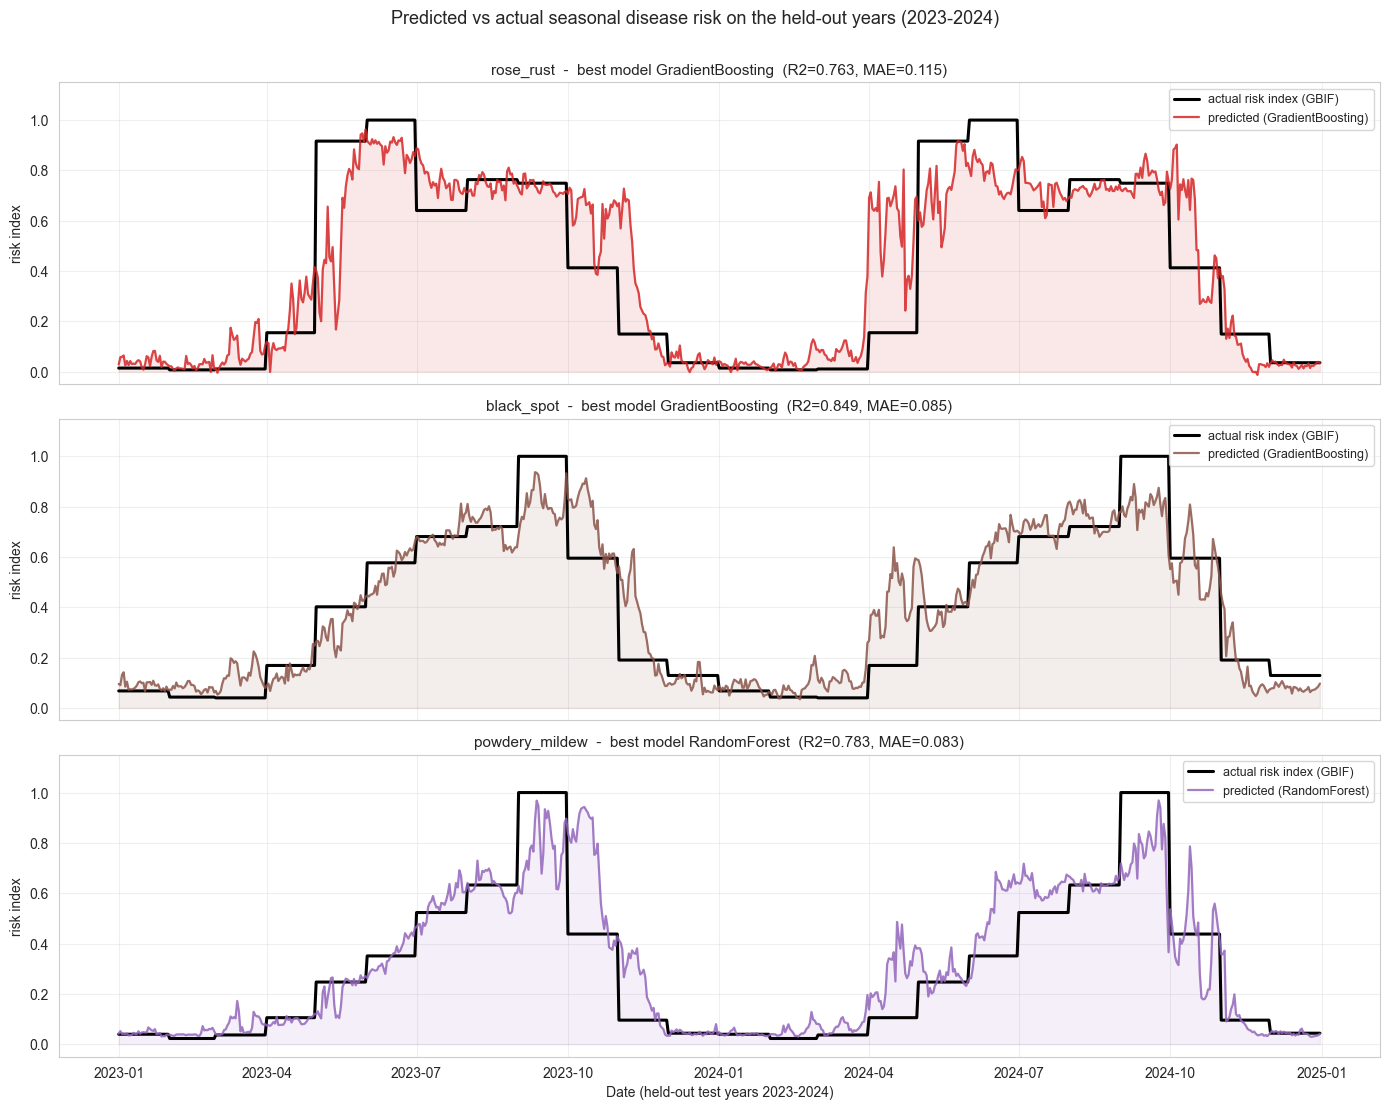

In [13]:
# ============================================================
# Predicted vs actual risk over the test period, per disease (best model)
# ============================================================
best_model = {d: max(MODEL_NAMES, key=lambda n: results[(d, n)]["r2"]) for d in DISEASES}
test_dates = df.loc[test_mask, "date"].values

colors = {"rose_rust": "#d62728", "black_spot": "#8c564b", "powdery_mildew": "#9467bd"}

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for ax, disease in zip(axes, DISEASES):
    y_true = y_test_by_disease[disease]
    y_pred = predictions[(disease, best_model[disease])]
    ax.plot(test_dates, y_true, color="black", linewidth=2.2,
            label="actual risk index (GBIF)")
    ax.plot(test_dates, y_pred, color=colors[disease], alpha=0.85, linewidth=1.6,
            label=f"predicted ({best_model[disease]})")
    ax.fill_between(test_dates, y_pred, alpha=0.10, color=colors[disease])
    ax.set_title(
        f"{disease}  -  best model {best_model[disease]}  "
        f"(R2={results[(disease, best_model[disease])]['r2']:.3f}, "
        f"MAE={results[(disease, best_model[disease])]['mae']:.3f})",
        fontsize=11,
    )
    ax.set_ylabel("risk index")
    ax.set_ylim(-0.05, 1.15)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date (held-out test years 2023-2024)")
fig.suptitle(
    "Predicted vs actual seasonal disease risk on the held-out years (2023-2024)",
    fontsize=13, y=1.005,
)
plt.tight_layout()
plt.show()

### Observations

The predicted daily risk tracks the seasonal shape of all three diseases
across both held-out years (2023 and 2024), confirming the models
generalise across years rather than memorising one:

- **rose_rust** — the prediction climbs sharply in **April–May**, tracks the
  May–Jun peak and the summer plateau, then falls in autumn. This is the key
  validation: the model places rust risk **in spring**, consistent with the
  GBIF season and the documented mid-May field observation. It is also the
  noisiest of the three (lowest R², 0.763) — daily weather scatter around the
  spring onset is where most of the error sits.
- **black_spot** — the cleanest fit (R² 0.849): the prediction follows the
  smooth ramp to the September peak and back down with little scatter.
- **powdery_mildew** — captures the sharp autumn peak well, staying low until
  midsummer then rising to September.

The predicted curve is **noisier than the actual one** by construction: the
target is a monthly step (a seasonal aggregate), while the prediction
responds to **daily** weather. The fact that daily weather alone reconstructs
the monthly seasonal curve this closely is the substantive result — and it is
strongest where the season is smooth (black_spot) and hardest at sharp
spring onsets (rose_rust).

## Visualisation: Feature Importance — Which Weather Drives Each Disease

This directly addresses hypothesis **H2**: *which* weather variables predict
risk. Two complementary views:

- **RandomForest importance** (left) — how much each feature contributes to
  the tree models' predictions (magnitude only, always positive).
- **Ridge coefficients** (right) — direction *and* magnitude of each
  feature's linear effect. Because the features were standardised, the
  coefficients are directly comparable across features.

Reading them together shows both *how important* a feature is and *in which
direction* it pushes risk.

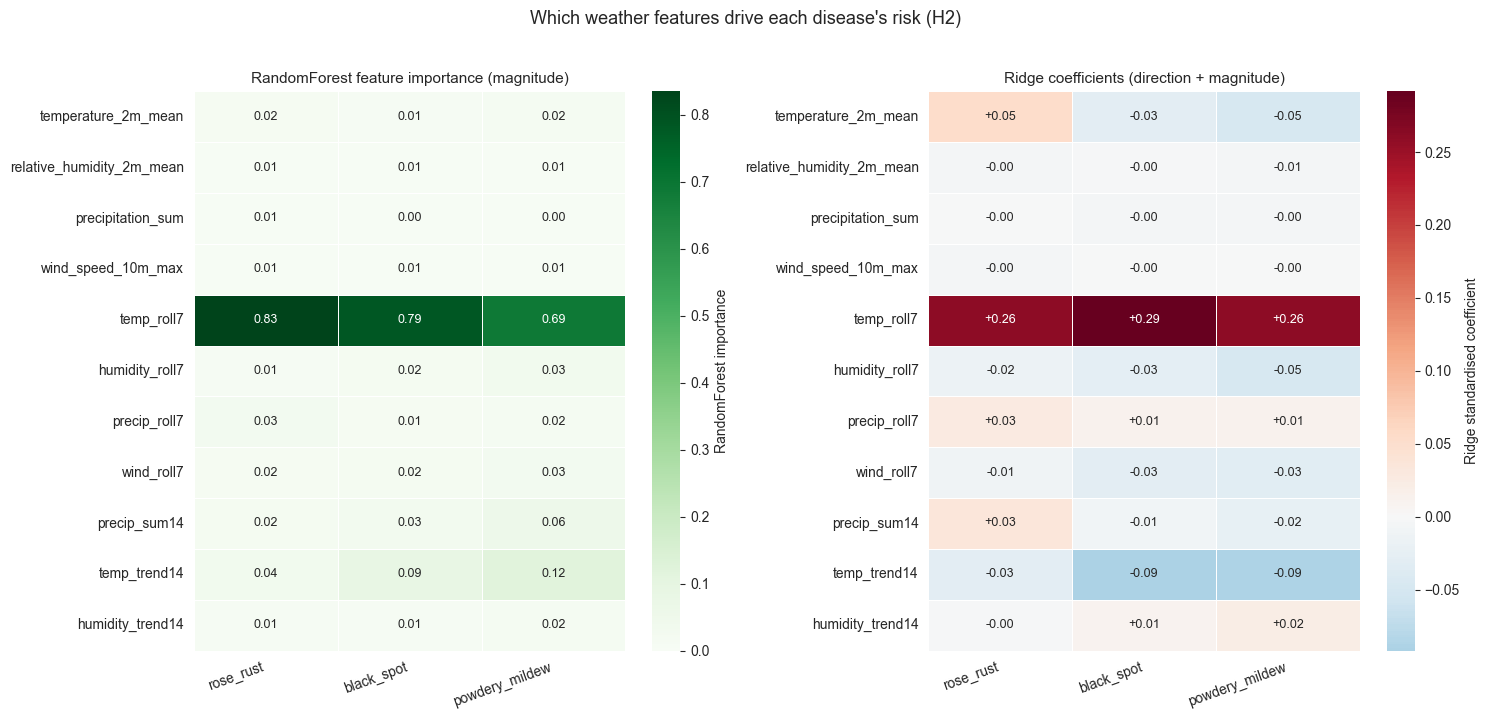

Top 3 features by RandomForest importance per disease:
  rose_rust       : temp_roll7 (0.83), temp_trend14 (0.04), precip_roll7 (0.03)
  black_spot      : temp_roll7 (0.79), temp_trend14 (0.09), precip_sum14 (0.03)
  powdery_mildew  : temp_roll7 (0.69), temp_trend14 (0.12), precip_sum14 (0.06)


In [14]:
# ============================================================
# Feature importance (RandomForest) and Ridge coefficients per disease
# ============================================================
rf_imp = pd.DataFrame(
    {d: models_fitted[(d, "RandomForest")].feature_importances_ for d in DISEASES},
    index=FEATURE_COLS,
)
ridge_coef = pd.DataFrame(
    {d: models_fitted[(d, "Ridge")].coef_ for d in DISEASES},
    index=FEATURE_COLS,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.heatmap(rf_imp, annot=True, fmt=".2f", cmap="Greens", vmin=0,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "RandomForest importance"},
            annot_kws={"fontsize": 9}, ax=axes[0])
axes[0].set_title("RandomForest feature importance (magnitude)", fontsize=11)

sns.heatmap(ridge_coef, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Ridge standardised coefficient"},
            annot_kws={"fontsize": 9}, ax=axes[1])
axes[1].set_title("Ridge coefficients (direction + magnitude)", fontsize=11)

for ax in axes:
    plt.setp(ax.get_yticklabels(), rotation=0)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

fig.suptitle("Which weather features drive each disease's risk (H2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Top features per disease (by RandomForest importance)
# ============================================================
print("Top 3 features by RandomForest importance per disease:")
for d in DISEASES:
    s = rf_imp[d].sort_values(ascending=False)
    print(f"  {d:<16}: " + ", ".join(f"{f} ({v:.2f})" for f, v in s.head(3).items()))

### Observations (answering H2)

The importance analysis gives a clear, and partly surprising, answer to H2:

- **Recent mean temperature dominates all three diseases.** `temp_roll7`
  carries 0.69–0.83 of the RandomForest importance and the largest positive
  Ridge coefficient (+0.26 to +0.29). Risk rises with the 7-day average
  temperature — the single strongest, and shared, driver.
- **The 14-day temperature trend is the key secondary, discriminating
  feature** — and, against the initial expectation, it matters **most for
  the autumn diseases**: importance grows 0.04 (rust) -> 0.09 (black_spot)
  -> 0.12 (powdery_mildew). Its Ridge coefficient is **negative** for the
  autumn diseases (-0.09): their risk peaks as temperatures **fall** in
  autumn. Rust is elevated across the whole warm season, so temperature
  alone already explains it and the trend adds little — which is why rust's
  importance is concentrated almost entirely in `temp_roll7`.
- **Same-day temperature and humidity are near-zero in importance** because
  their smoothed 7-day versions (`temp_roll7`, `humidity_roll7`) absorb the
  same signal — the rolling features make the raw daily ones redundant. This
  supports H2's "7 days prior" framing: the weekly average beats the single
  day.
- **Precipitation and wind are weak predictors** at this seasonal
  resolution (importance <= 0.06). This does not disprove their biological
  role in infection, but against a monthly seasonal target they carry little
  signal beyond temperature.

**H2 verdict:** among the variables tested, **temperature — especially its
recent 7-day average — is the significant predictor of seasonal risk**,
with the 14-day temperature trend as a meaningful secondary signal that
separates the autumn-peaking diseases. Humidity, precipitation and wind are
weak at this resolution.

## Validation Against the Field Observation

The one documented local ground-truth is rust present at Krasnovo in
**mid-May 2026**. No 2026 weather is in this dataset, so this is a
qualitative check: does the rust model place **elevated risk in mid-May**
of the held-out test years (2023–2024)? If the model independently predicts
high rust risk in the same calendar window where rust was actually
observed, that is real (if limited) corroboration.

Predicted rust risk in mid-May (May 10-16) of the test years:
  2023-05-10 : 0.44
  2023-05-11 : 0.50
  2023-05-12 : 0.33
  2023-05-13 : 0.17
  2023-05-14 : 0.22
  2023-05-15 : 0.28
  2023-05-16 : 0.48
  2024-05-10 : 0.61
  2024-05-11 : 0.71
  2024-05-12 : 0.82
  2024-05-13 : 0.63
  2024-05-14 : 0.68
  2024-05-15 : 0.49
  2024-05-16 : 0.53

  mid-May mean predicted rust risk : 0.49
  annual  mean predicted rust risk : 0.43
  mid-May risk is higher than 50% of all days in the year


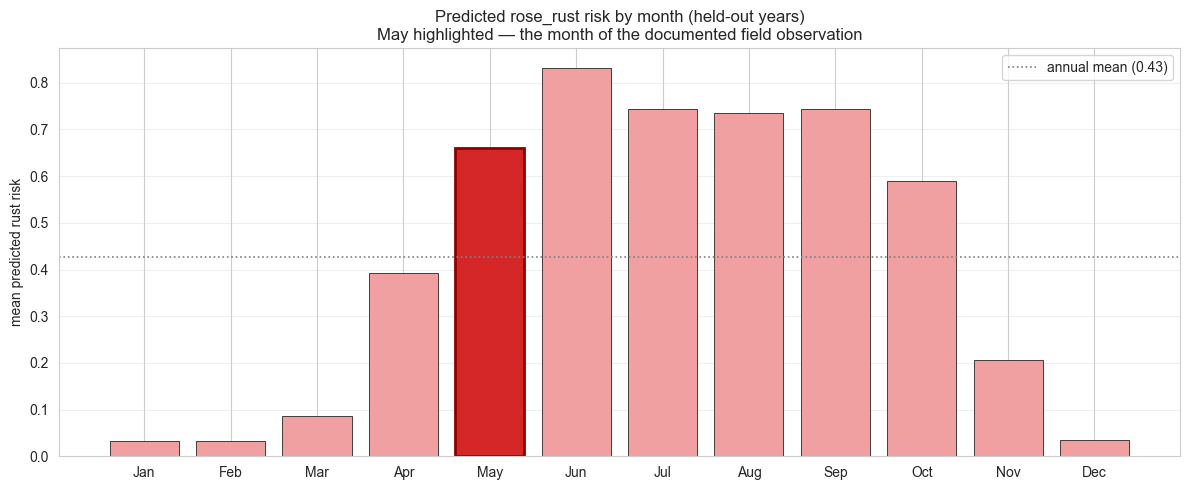

In [15]:
# ============================================================
# Predicted rust risk in mid-May of the test years vs the annual level
# ============================================================
rust_pred = predictions[("rose_rust", best_model["rose_rust"])]
test_df = df.loc[test_mask, ["date"]].copy().reset_index(drop=True)
test_df["rust_pred"] = rust_pred
test_df["month"] = test_df["date"].dt.month

# Field observation window: around May 10-16
midmay = test_df[(test_df["month"] == 5) & (test_df["date"].dt.day.between(10, 16))]

print("Predicted rust risk in mid-May (May 10-16) of the test years:")
for _, r in midmay.iterrows():
    print(f"  {r['date'].date()} : {r['rust_pred']:.2f}")

midmay_mean = midmay["rust_pred"].mean()
annual_mean = test_df["rust_pred"].mean()
pct = (test_df["rust_pred"] < midmay_mean).mean()
print(f"\n  mid-May mean predicted rust risk : {midmay_mean:.2f}")
print(f"  annual  mean predicted rust risk : {annual_mean:.2f}")
print(f"  mid-May risk is higher than {pct:.0%} of all days in the year")

# ============================================================
# Mean predicted rust risk per month (test years), mid-May highlighted
# ============================================================
monthly_rust = test_df.groupby("month")["rust_pred"].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(1, 13), monthly_rust.values, color="#f0a0a0",
              edgecolor="black", linewidth=0.5)
bars[4].set_color("#d62728")   # May
bars[4].set_edgecolor("darkred")
bars[4].set_linewidth(2)

ax.axhline(annual_mean, color="gray", linestyle=":", linewidth=1.2,
           label=f"annual mean ({annual_mean:.2f})")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel("mean predicted rust risk")
ax.set_title(
    "Predicted rose_rust risk by month (held-out years)\n"
    "May highlighted — the month of the documented field observation",
    fontsize=12,
)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Observations

The model independently places rust risk in spring, consistent with the
field observation — with an honest caveat about year-to-year variation:

- **Monthly view (the clear signal):** mean predicted rust risk in **May is
  0.66**, well above the annual mean of 0.43, on a **rising trajectory**
  from April (0.39) into the June peak (0.83). The model puts May firmly in
  the elevated part of the year — the same window in which rust was observed
  in the field.
- **Daily view (the honest nuance):** the mid-May daily values vary
  substantially **between years** — 2024 was strongly elevated (up to 0.82
  on May 12) while 2023 was only moderate (0.17–0.50). This is expected and
  correct behaviour: the model responds to *each year's actual weather*, not
  to a fixed calendar value. A cooler/different spring produces lower
  predicted risk even in May.
- The "higher than 50% of days" figure is modest mainly because the dormant
  half-year (Nov–Mar) sits near zero; the **monthly comparison (0.66 vs
  0.43)** is the more informative statement.

**Scope of this validation:** it is **corroboration, not proof** — a single
qualitative field observation, from a year (2026) not in the training data.
Within those limits, the model's spring placement of rust risk agrees with
the one piece of local ground truth available.

## Conclusions

Notebook 08 built **per-disease weather-driven risk models** for the three
fungal diseases of Rosa damascena with sufficient GBIF data (rose_rust,
black_spot, powdery_mildew), trained on Krasnovo weather (2015–2024).

### What Was Done

- **Honest target:** a continuous seasonal risk index per disease, derived
  from real **GBIF occurrence seasonality** (no fabricated daily field
  labels). A first binary attempt was rejected because a simple threshold
  collapsed all three diseases to the same season — documented as part of
  the method.
- **Weather-only features** with 7-day rolling means, 14-day cumulative
  precipitation, and 14-day temperature/humidity **trends** — no calendar
  input, so the models infer risk from actual weather.
- **Time-aware split** (train 2015–2022, test 2023–2024) and three sklearn
  regressors per disease (Ridge + RandomForest + GradientBoosting).

### Results

| Disease | Best model | Test R² | MAE |
|---|---|---|---|
| rose_rust | GradientBoosting | 0.763 | 0.115 |
| black_spot | GradientBoosting | 0.849 | 0.085 |
| powdery_mildew | RandomForest | 0.783 | 0.083 |

- **Tree-based models beat Ridge on every disease** (+0.07 to +0.10 R²):
  the per-disease seasonal distinction lives in **non-linear interactions**,
  not in the shared linear temperature signal.
- **H2 answer:** the **7-day mean temperature** is the dominant predictor
  for all three diseases, with the **14-day temperature trend** as the key
  secondary signal — strongest for the autumn-peaking diseases, where risk
  rises as temperatures fall. Humidity, precipitation and wind are weak at
  this seasonal resolution.
- Weather alone explains **76–85% of the seasonal risk variance**.
- The rust model places elevated risk in **mid-May**, consistent with the
  documented field observation.

### Limitations (stated honestly)

- The target is **GBIF-derived seasonality**, which reflects observer effort
  as well as true presence; there are **no local daily field labels**, so
  this is a seasonal/climatic risk model, not a field-validated outbreak
  classifier.
- `downy_mildew` was excluded for insufficient data.
- Precipitation/wind carried little signal at monthly resolution — this does
  not rule out their biological role at finer (daily infection-event) scales.

### Hand-Off

- **Notebook 09 (MLflow):** logs these three regression models and their
  metrics alongside the image classifiers (tracked as a separate task — risk
  regression, not the image-classification ladder).
- **Project deliverable:** the fungicide-recommendation logic combines
  **notebook 07** (image diagnosis: which disease) with **notebook 08**
  (weather context: is the risk window active) to decide whether treatment
  is warranted.

## Saving Models and Results

Following the convention of notebooks 06 and 07, all trained artifacts are
saved to `models/` so notebook 09 (MLflow) can load them without retraining:

- the nine fitted regressors (3 diseases x 3 models) and the feature scaler,
- a JSON with metrics, the feature list, the per-disease risk-index
  definition and the train/test split,
- the test-set predictions and ground truth for every model.

In [16]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Fitted models (compressed) + the feature scaler
# ============================================================
for (disease, name), model in models_fitted.items():
    joblib.dump(model, MODELS_DIR / f"08_{disease}_{name}.joblib", compress=3)
joblib.dump(scaler, MODELS_DIR / "08_feature_scaler.joblib", compress=3)

# ============================================================
# 2. Metrics + config as JSON (human-readable, tiny)
# ============================================================
meta = {
    "diseases":     list(DISEASES.keys()),
    "feature_cols": FEATURE_COLS,
    "model_names":  MODEL_NAMES,
    "best_model":   best_model,
    "train_years":  TRAIN_YEARS,
    "test_years":   TEST_YEARS,
    "risk_index":   {d: risk_index.loc[d].round(4).to_dict() for d in DISEASES},
    "results": {
        f"{disease}__{name}": {
            "r2":  round(results[(disease, name)]["r2"], 4),
            "mae": round(results[(disease, name)]["mae"], 4),
        }
        for disease in DISEASES for name in MODEL_NAMES
    },
}
with open(MODELS_DIR / "08_weather_risk_results.json", "w") as f:
    json.dump(meta, f, indent=2)

# ============================================================
# 3. Test predictions + ground truth (for notebook 09)
# ============================================================
np.savez(
    MODELS_DIR / "08_test_predictions.npz",
    test_dates=df.loc[test_mask, "date"].values.astype("datetime64[D]").astype(str),
    **{f"y_true_{d}": y_test_by_disease[d] for d in DISEASES},
    **{f"y_pred_{d}_{n}": predictions[(d, n)] for d in DISEASES for n in MODEL_NAMES},
)

# ============================================================
# 4. Report saved files and sizes
# ============================================================
print(f"Saved to {MODELS_DIR}:")
total = 0
for p in sorted(MODELS_DIR.glob("08_*")):
    kb = p.stat().st_size / 1024
    total += kb
    print(f"  {p.name:<45} {kb:>8.1f} KB")
print(f"  {'TOTAL':<45} {total:>8.1f} KB")

Saved to h:\SoftUni\Machine Learning\Machine_Learning_Project\models:
  08_black_spot_GradientBoosting.joblib             42.9 KB
  08_black_spot_RandomForest.joblib               5400.7 KB
  08_black_spot_Ridge.joblib                         0.5 KB
  08_feature_scaler.joblib                           0.7 KB
  08_powdery_mildew_GradientBoosting.joblib         43.6 KB
  08_powdery_mildew_RandomForest.joblib           5479.8 KB
  08_powdery_mildew_Ridge.joblib                     0.5 KB
  08_rose_rust_GradientBoosting.joblib              42.6 KB
  08_rose_rust_RandomForest.joblib                5663.5 KB
  08_rose_rust_Ridge.joblib                          0.5 KB
  08_test_predictions.npz                          152.1 KB
  08_weather_risk_results.json                       2.3 KB
  TOTAL                                          16829.7 KB
